In [488]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [489]:
data = pd.read_csv('/content/BikeRentalData.csv')

In [490]:
data.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,registered,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,13,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,32,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,27,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,10,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1


In [491]:
data.tail()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,registered,cnt
17374,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,108,119
17375,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,81,89
17376,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,83,90
17377,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,48,61
17378,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,37,49


In [492]:
data.shape

(17379, 14)

In [493]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   yr          17379 non-null  int64  
 2   mnth        17379 non-null  int64  
 3   hr          17379 non-null  int64  
 4   holiday     17379 non-null  int64  
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  int64  
 7   weathersit  17379 non-null  int64  
 8   temp        17379 non-null  float64
 9   atemp       17379 non-null  float64
 10  hum         17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  registered  17379 non-null  int64  
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(10)
memory usage: 1.9 MB


In [494]:
data.isnull().sum()

,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
atemp,0


In [495]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000


In [496]:
def time_category(hour):
    if 7 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 16:
        return 'Afternoon'
    elif 16 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'   # covers 21–24 AND 0–7
data['time_bucket'] = data['hr'].apply(time_category)

In [497]:
# as we have only numerial col we will divide them into continous and discrete

In [498]:
continous_col = []
discrete_col = []
for i in data.columns:
    if data[i].nunique() >=15 :
        continous_col.append(i)
    else :
        discrete_col.append(i)

In [499]:
continous_col

['hr', 'temp', 'atemp', 'hum', 'windspeed', 'registered', 'cnt']

In [500]:
discrete_col

['season',
 'yr',
 'mnth',
 'holiday',
 'weekday',
 'workingday',
 'weathersit',
 'time_bucket']

In [501]:
# cnt will be our target col .. we will predict the expected no. of bike that can be rented on that day

# Lets Start with EDA

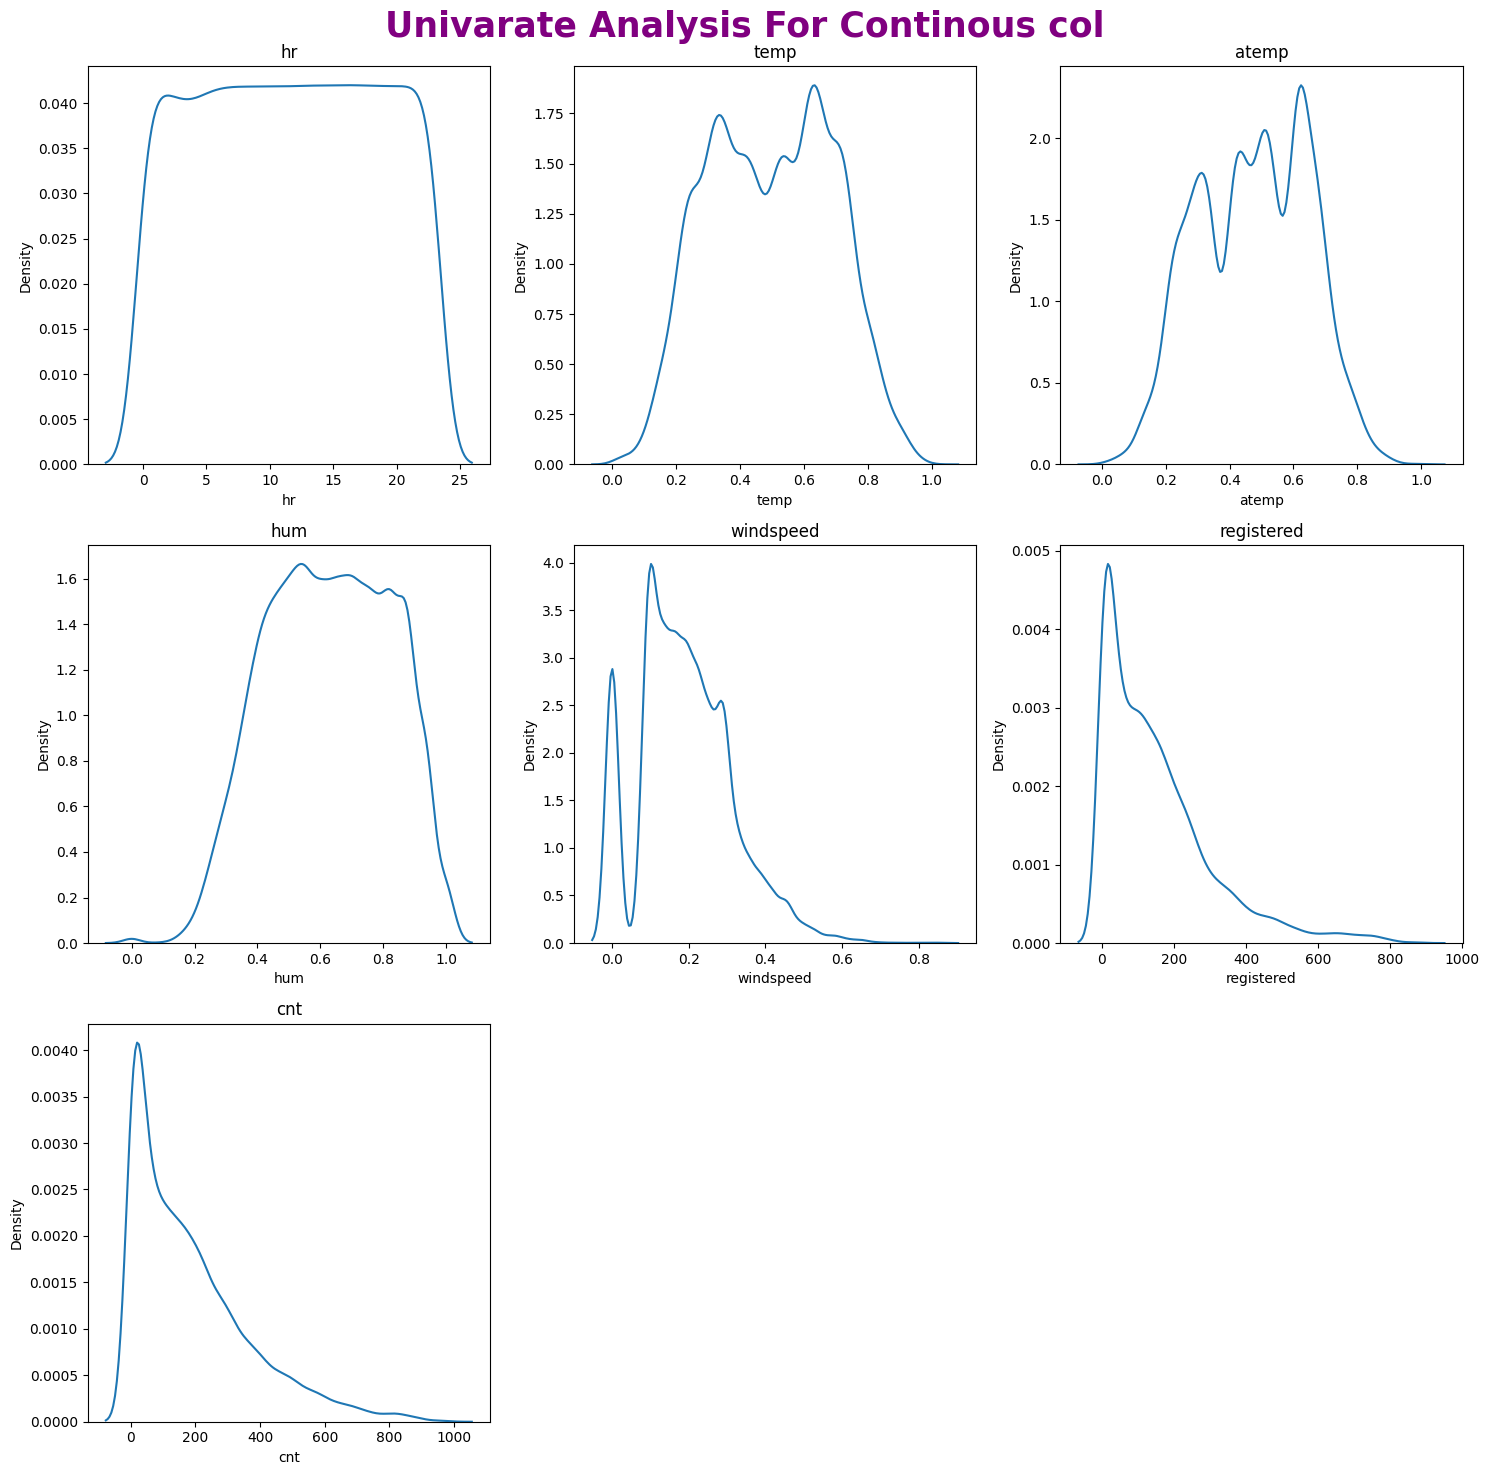

In [502]:
# univarate analysis for continous col
plt.figure(figsize = (15,15))
plt.suptitle("Univarate Analysis For Continous col",fontweight = 'bold' , fontsize = 25 , color = 'purple')

for i in range(len(continous_col)):
    plt.subplot(3,3,i+1)
    sns.kdeplot(data[continous_col[i]])
    plt.title(continous_col[i])

plt.tight_layout()
plt.show()


In [503]:
data_yr1 = data[data['yr']==1]
data_yr0 = data[data['yr']==0]

In [504]:
data_yr1.shape,data_yr0.shape

((8734, 15), (8645, 15))

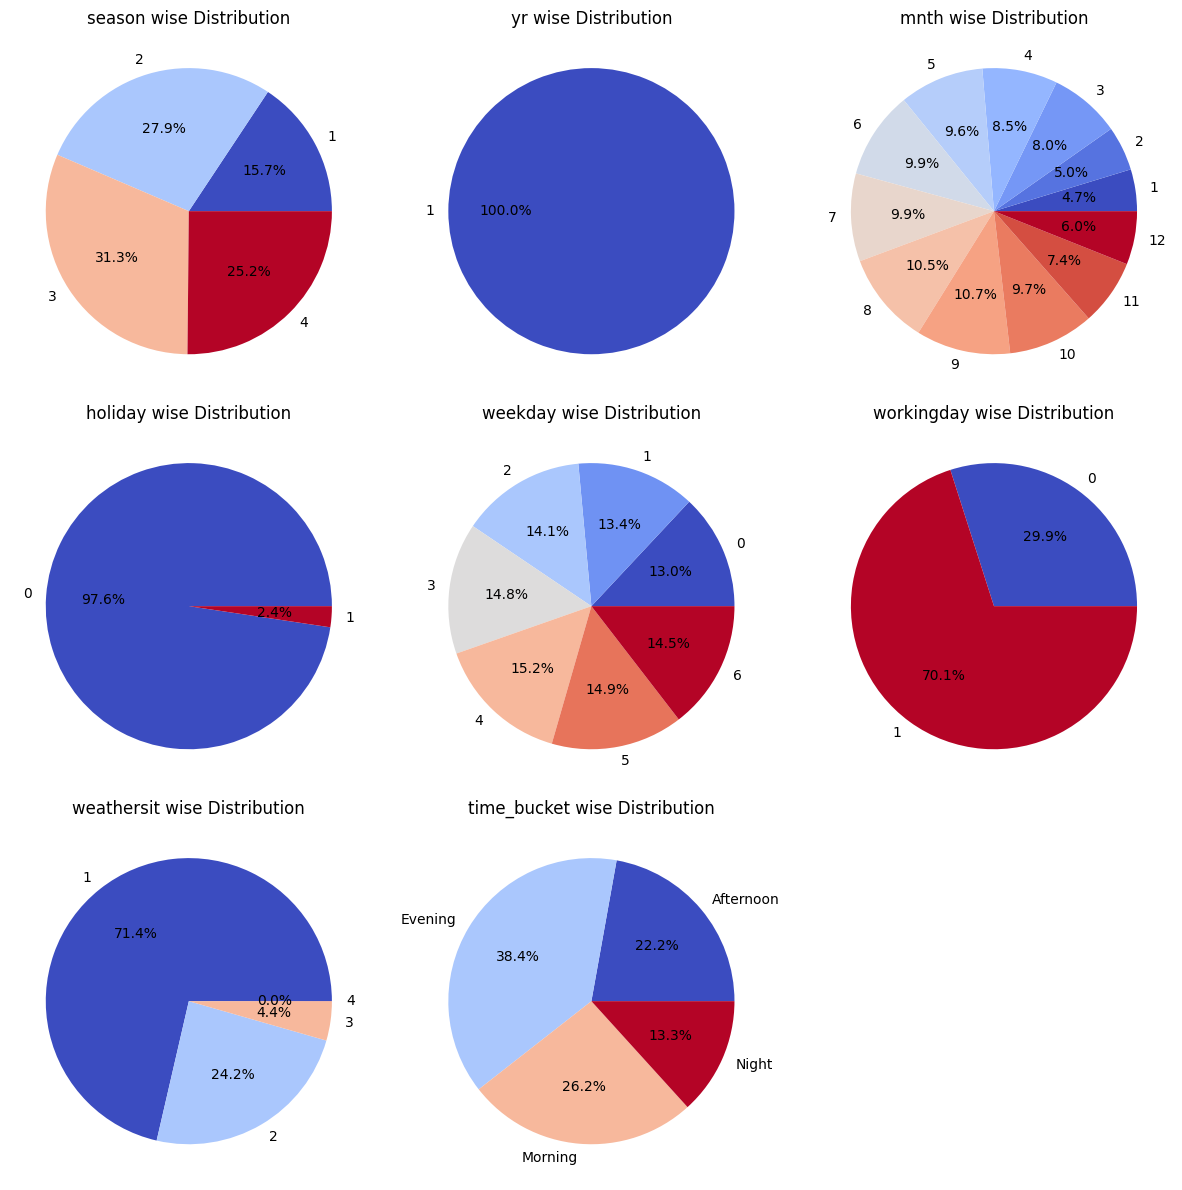

In [505]:
plt.figure(figsize=(12,12))

for i in range(len(discrete_col)):
    plt.subplot(3,3,i+1)
    helper = data_yr1.groupby(discrete_col[i])['cnt'].sum()
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(helper)))
    plt.pie(helper.values, labels=helper.index, autopct='%1.1f%%', colors=colors)
    plt.title(f"{discrete_col[i]} wise Distribution")

plt.tight_layout()
plt.show()

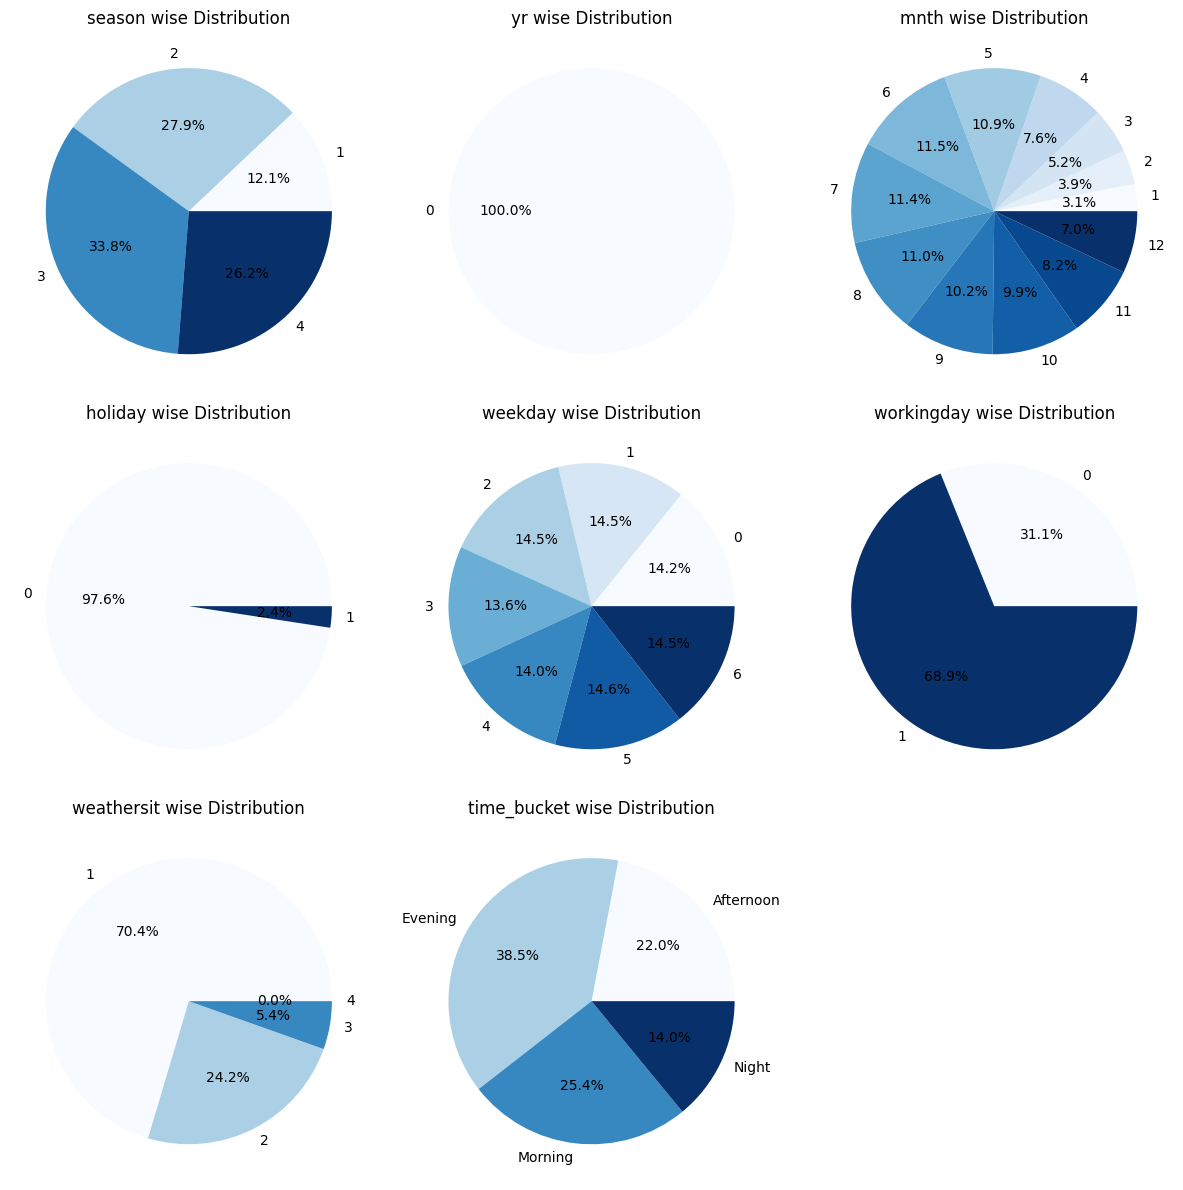

In [506]:
plt.figure(figsize=(12,12))

for i in range(len(discrete_col)):
    plt.subplot(3,3,i+1)
    helper = data_yr0.groupby(discrete_col[i])['cnt'].sum()
    colors = plt.cm.Blues(np.linspace(0, 1, len(helper)))
    plt.pie(helper.values, labels=helper.index, autopct='%1.1f%%', colors=colors)
    plt.title(f"{discrete_col[i]} wise Distribution")

plt.tight_layout()
plt.show()

Insghts So far ->
  hour temperature atemp humidity follows normal distribution , while windspeed regestered and cnt are left skewed

Our Data is balanced with resepect to weekday , year , month , and Season

Distribution WRT Number Of Bike Rented

SEASON -> in season 3 highest number of bikes were rented and in season 1 it is least number of bikes that were rented
Year -> Year 0 has lesser amount of bike rented (32%) and year 1 has (62%) of bike rented

similarly for more you can go through the visual shown

In [507]:
data.columns

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'registered', 'cnt',
       'time_bucket'],
      dtype='object')

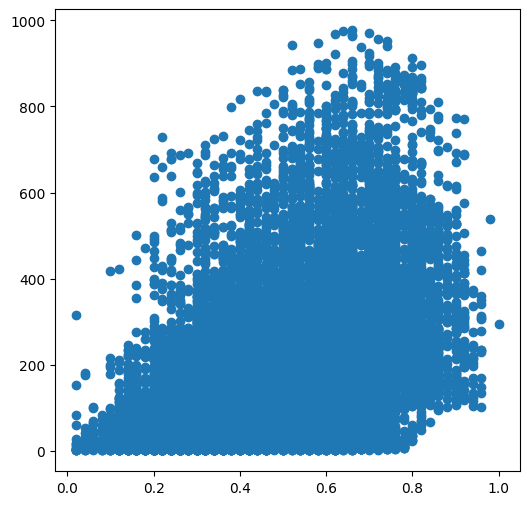

In [508]:
plt.figure(figsize=(6,6))

plt.scatter(data['temp'],data['cnt'])
plt.show()

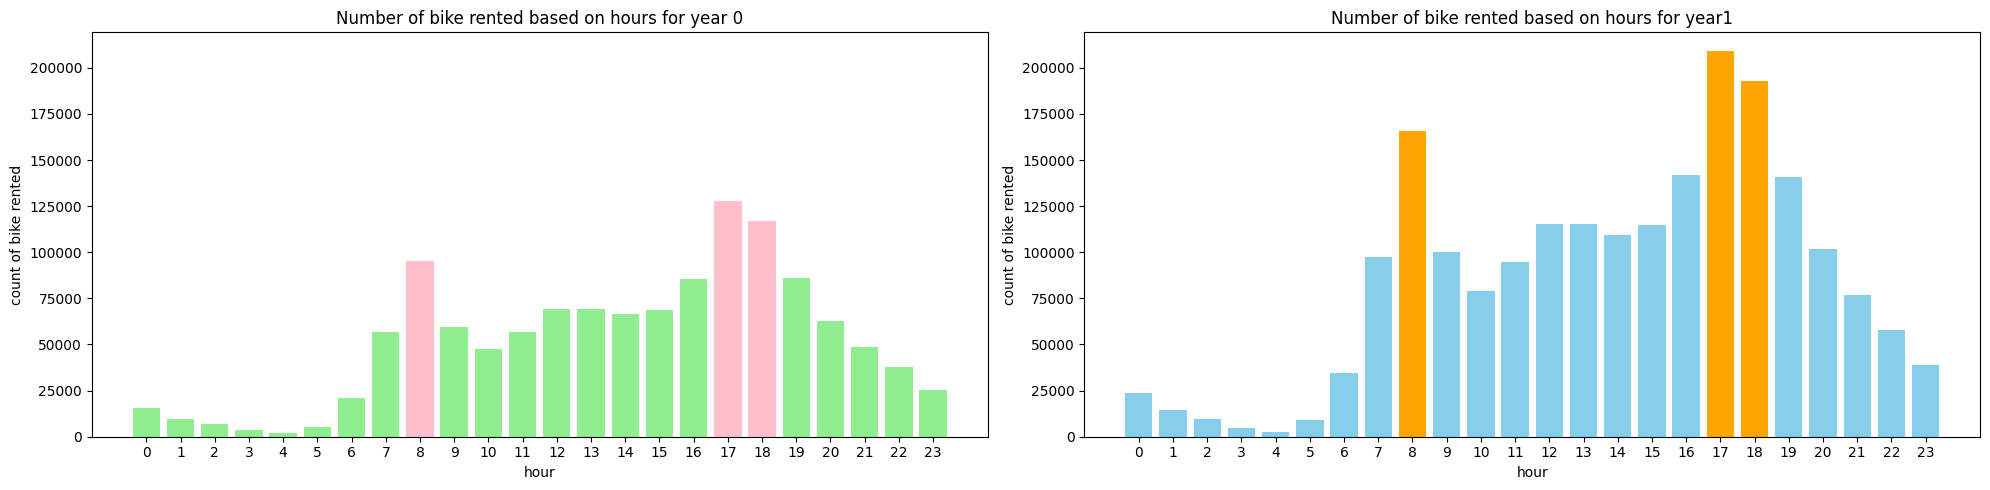

In [509]:


plt.figure(figsize=(20,5))

helper = data_yr1.groupby('hr')['cnt'].sum()
colors = ['orange' if x >= helper.nlargest(3).min() else 'skyblue'
          for x in helper.values]

helper_2 = data_yr0.groupby('hr')['cnt'].sum()
colors_2 = ['pink' if x >= helper_2.nlargest(3).min() else 'lightgreen'
          for x in helper_2.values]
max_val = max(helper.values.max(), helper_2.values.max()) + 10000


plt.subplot(1,2,1)
plt.bar(helper_2.index, helper_2.values, color=colors_2)
plt.xticks(ticks=helper_2.index)
plt.xlabel("hour")
plt.ylabel("count of bike rented")
plt.ylim(0, max_val)
plt.title('Number of bike rented based on hours for year 0')

plt.subplot(1,2,2)
plt.bar(helper.index, helper.values, color=colors)
plt.xticks(ticks=helper.index)
plt.xlabel("hour")
plt.ylabel("count of bike rented")
plt.ylim(0, max_val)
plt.title('Number of bike rented based on hours for year1')


plt.tight_layout()
plt.show()

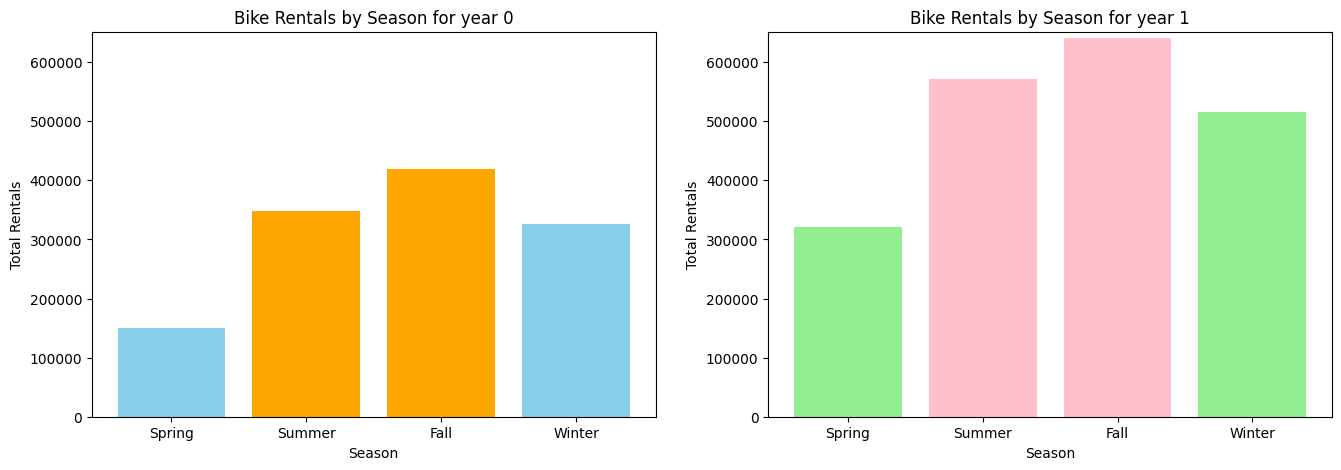

In [510]:

# mapping
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}
plt.figure(figsize=(16,5))


helper = data_yr0.groupby('season')['cnt'].sum()
helper.index = helper.index.map(season_map)
colors = ['orange' if x >= helper.nlargest(2).min() else 'skyblue'
          for x in helper.values]

helper_2 = data_yr1.groupby('season')['cnt'].sum()
helper_2.index = helper_2.index.map(season_map)
colors_2 = ['pink' if x >= helper_2.nlargest(2).min() else 'lightgreen'
          for x in helper_2.values]
max_val = max(helper.values.max(), helper_2.values.max()) + 10000

# plot1 1st year k liye
plt.subplot(1,2,1)
plt.bar(helper.index, helper.values, color=colors)
plt.xlabel("Season")
plt.ylabel("Total Rentals")
plt.ylim(0, max_val)
plt.title('Bike Rentals by Season for year 0')

# plot2 2 year k liye
plt.subplot(1,2,2)
plt.bar(helper_2.index, helper_2.values, color=colors_2)
plt.xlabel("Season")
plt.ylabel("Total Rentals")
plt.ylim(0, max_val)
plt.title('Bike Rentals by Season for year 1')

plt.show()

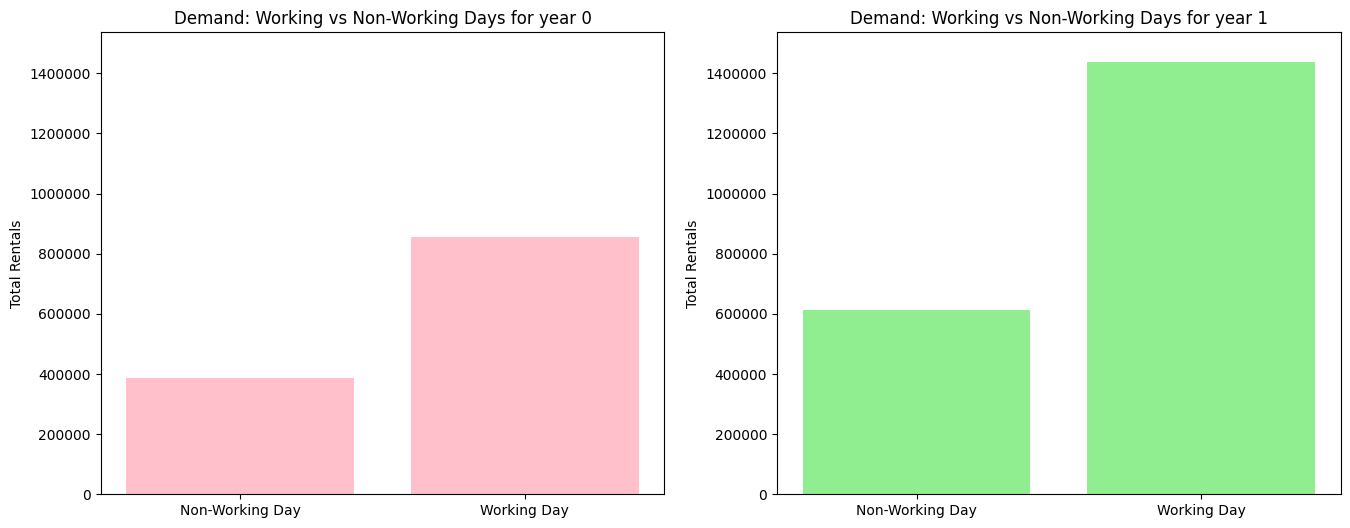

In [511]:
plt.figure(figsize=(16,6))
helper = data_yr0.groupby('workingday')['cnt'].sum()
helper_2 = data_yr1.groupby('workingday')['cnt'].sum()
max_val = max(helper.values.max(), helper_2.values.max()) + 100000

labels = ['Non-Working Day', 'Working Day']

plt.subplot(1,2,1)
plt.bar(labels, helper.values,color = ['pink'])
plt.title('Demand: Working vs Non-Working Days for year 0')
plt.ylim(0, max_val)
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel('Total Rentals')


plt.subplot(1,2,2)
plt.bar(labels, helper_2.values,color = ['Lightgreen'])
plt.title('Demand: Working vs Non-Working Days for year 1')
plt.ylim(0, max_val)
plt.ylabel('Total Rentals')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

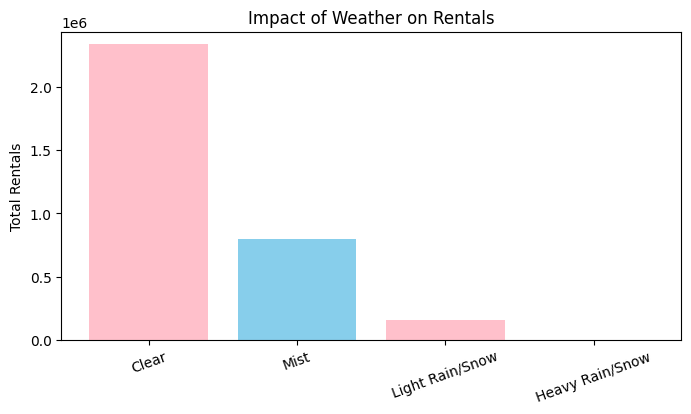

In [512]:
helper = data.groupby('weathersit')['cnt'].sum()

weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

helper.index = helper.index.map(weather_map)
max_val = max(helper.values.max(), helper_2.values.max()) + 100000

plt.figure(figsize=(8,4))
plt.bar(helper.index, helper.values,color=['Pink','Skyblue'])
plt.title('Impact of Weather on Rentals')
plt.ylabel('Total Rentals')
plt.ylim(0, max_val)
plt.xticks(rotation=20)
plt.show()

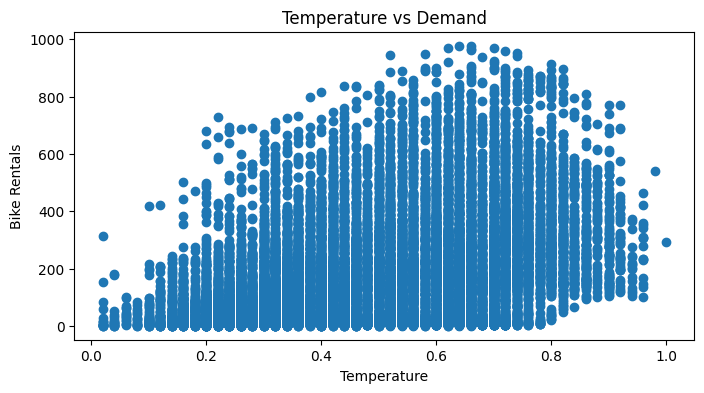

In [513]:
plt.figure(figsize=(8,4))
plt.scatter(data['temp'], data['cnt'])

plt.xlabel('Temperature')
plt.ylabel('Bike Rentals')
plt.title('Temperature vs Demand')

plt.show()

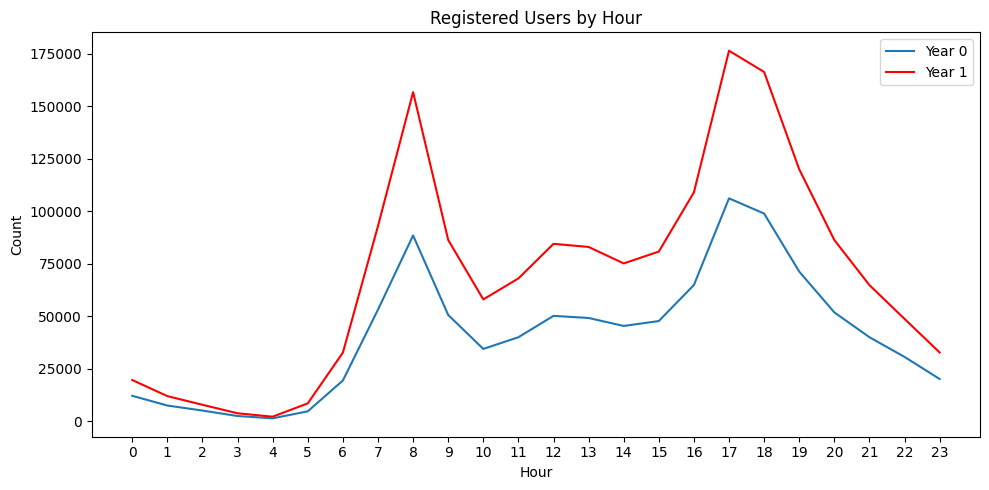

In [514]:
plt.figure(figsize=(10,5))
helper = data_yr0.groupby('hr')['registered'].sum()
helper_2 = data_yr1.groupby('hr')['registered'].sum()

plt.plot(helper.index, helper.values,label='Year 0')
plt.plot(helper_2.index, helper_2.values,color='Red',label='Year 1')
plt.xticks(range(24))
plt.title('Registered Users by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')

plt.legend()
plt.tight_layout()
plt.show()

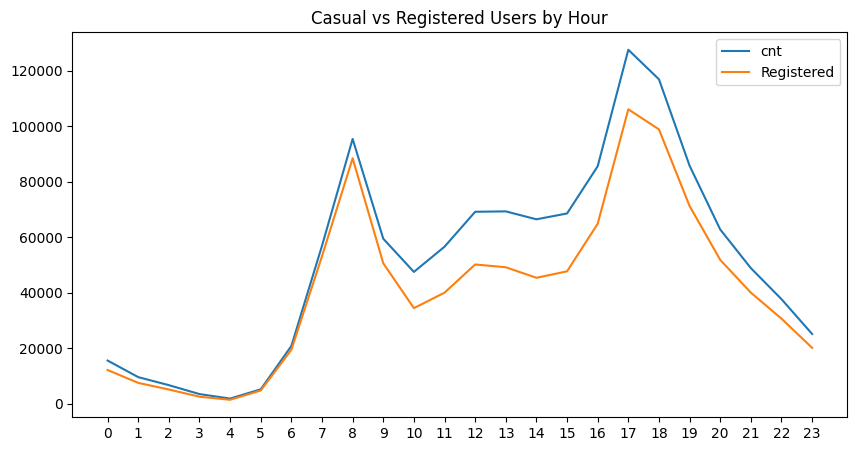

In [515]:
helper = data_yr0.groupby('hr')[['cnt','registered']].sum()

plt.figure(figsize=(10,5))
plt.plot(helper.index, helper['cnt'], label='cnt')
plt.plot(helper.index, helper['registered'], label='Registered')

plt.xticks(range(24))
plt.legend()
plt.title('Casual vs Registered Users by Hour')

plt.show()

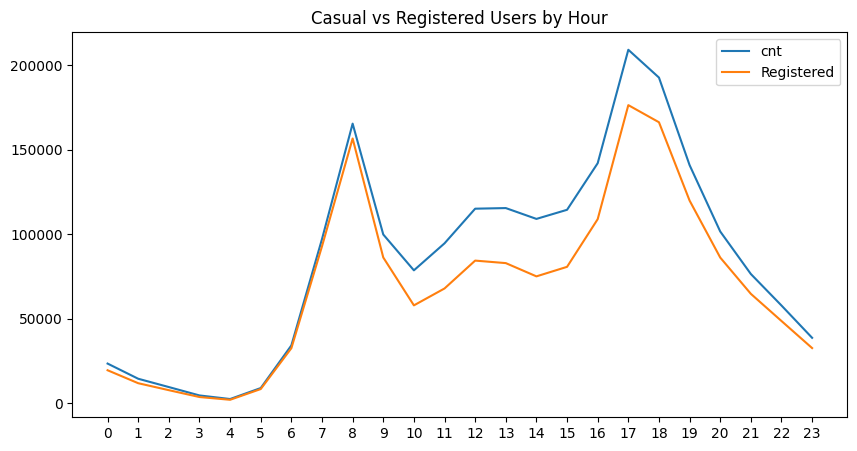

In [516]:
helper = data_yr1.groupby('hr')[['cnt','registered']].sum()

plt.figure(figsize=(10,5))
plt.plot(helper.index, helper['cnt'], label='cnt')
plt.plot(helper.index, helper['registered'], label='Registered')

plt.xticks(range(24))
plt.legend()
plt.title('Casual vs Registered Users by Hour')

plt.show()

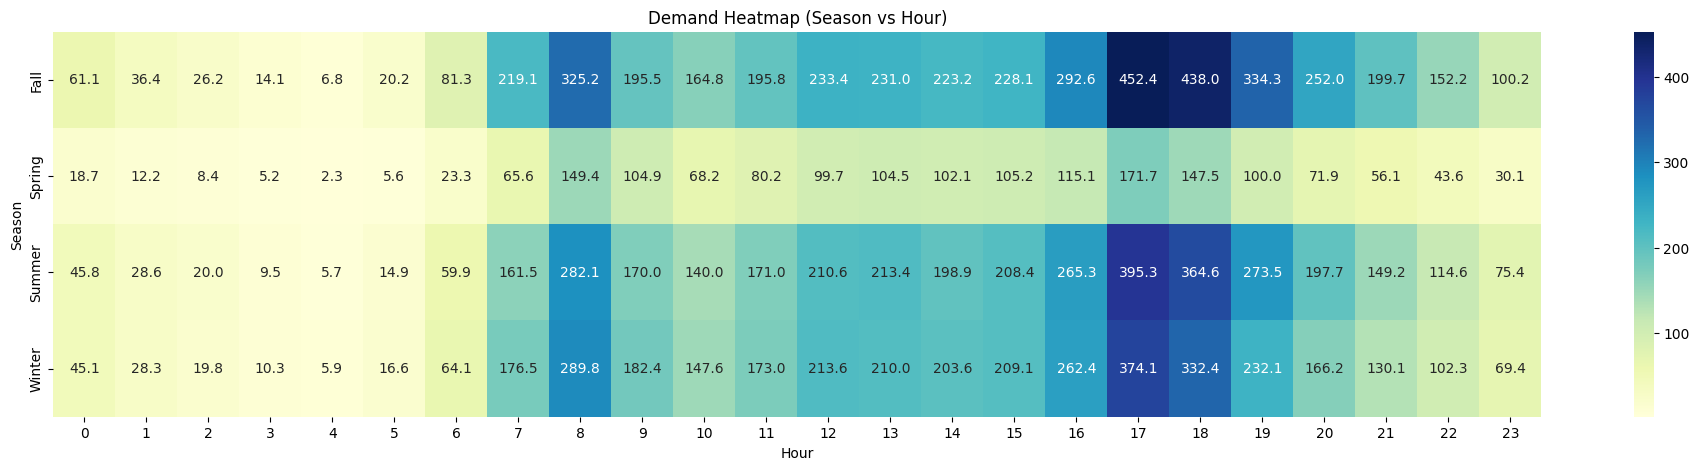

In [517]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

data_yr0['season_2'] = data_yr0['season'].map(season_map)

pivot = data_yr0.pivot_table(values='cnt', index='season_2', columns='hr')

plt.figure(figsize=(24,5))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".1f")

plt.title('Demand Heatmap (Season vs Hour)')
plt.xlabel('Hour')
plt.ylabel('Season')

plt.show()

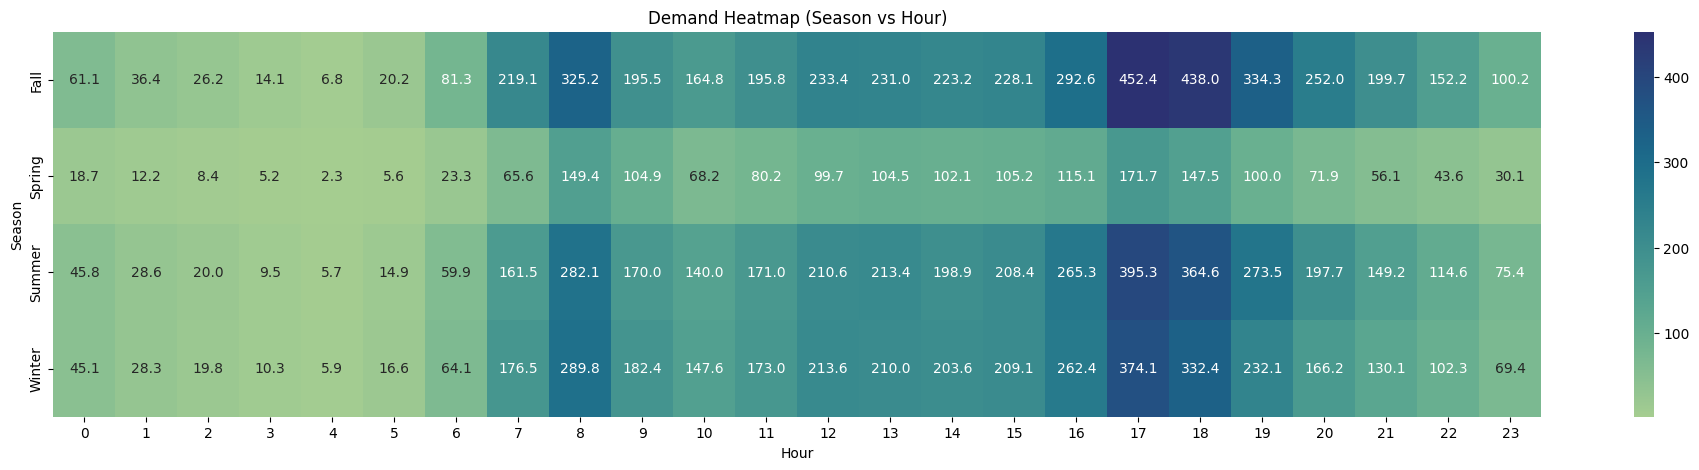

In [518]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

data_yr0['season_2'] = data_yr0['season'].map(season_map)

pivot = data_yr0.pivot_table(values='cnt', index='season_2', columns='hr')

plt.figure(figsize=(24,5))
sns.heatmap(pivot, cmap='crest', annot=True, fmt=".1f")

plt.title('Demand Heatmap (Season vs Hour)')
plt.xlabel('Hour')
plt.ylabel('Season')

plt.show()

# Feature Selection & Extraction

In [519]:
data = data.drop('time_bucket',axis = 1)

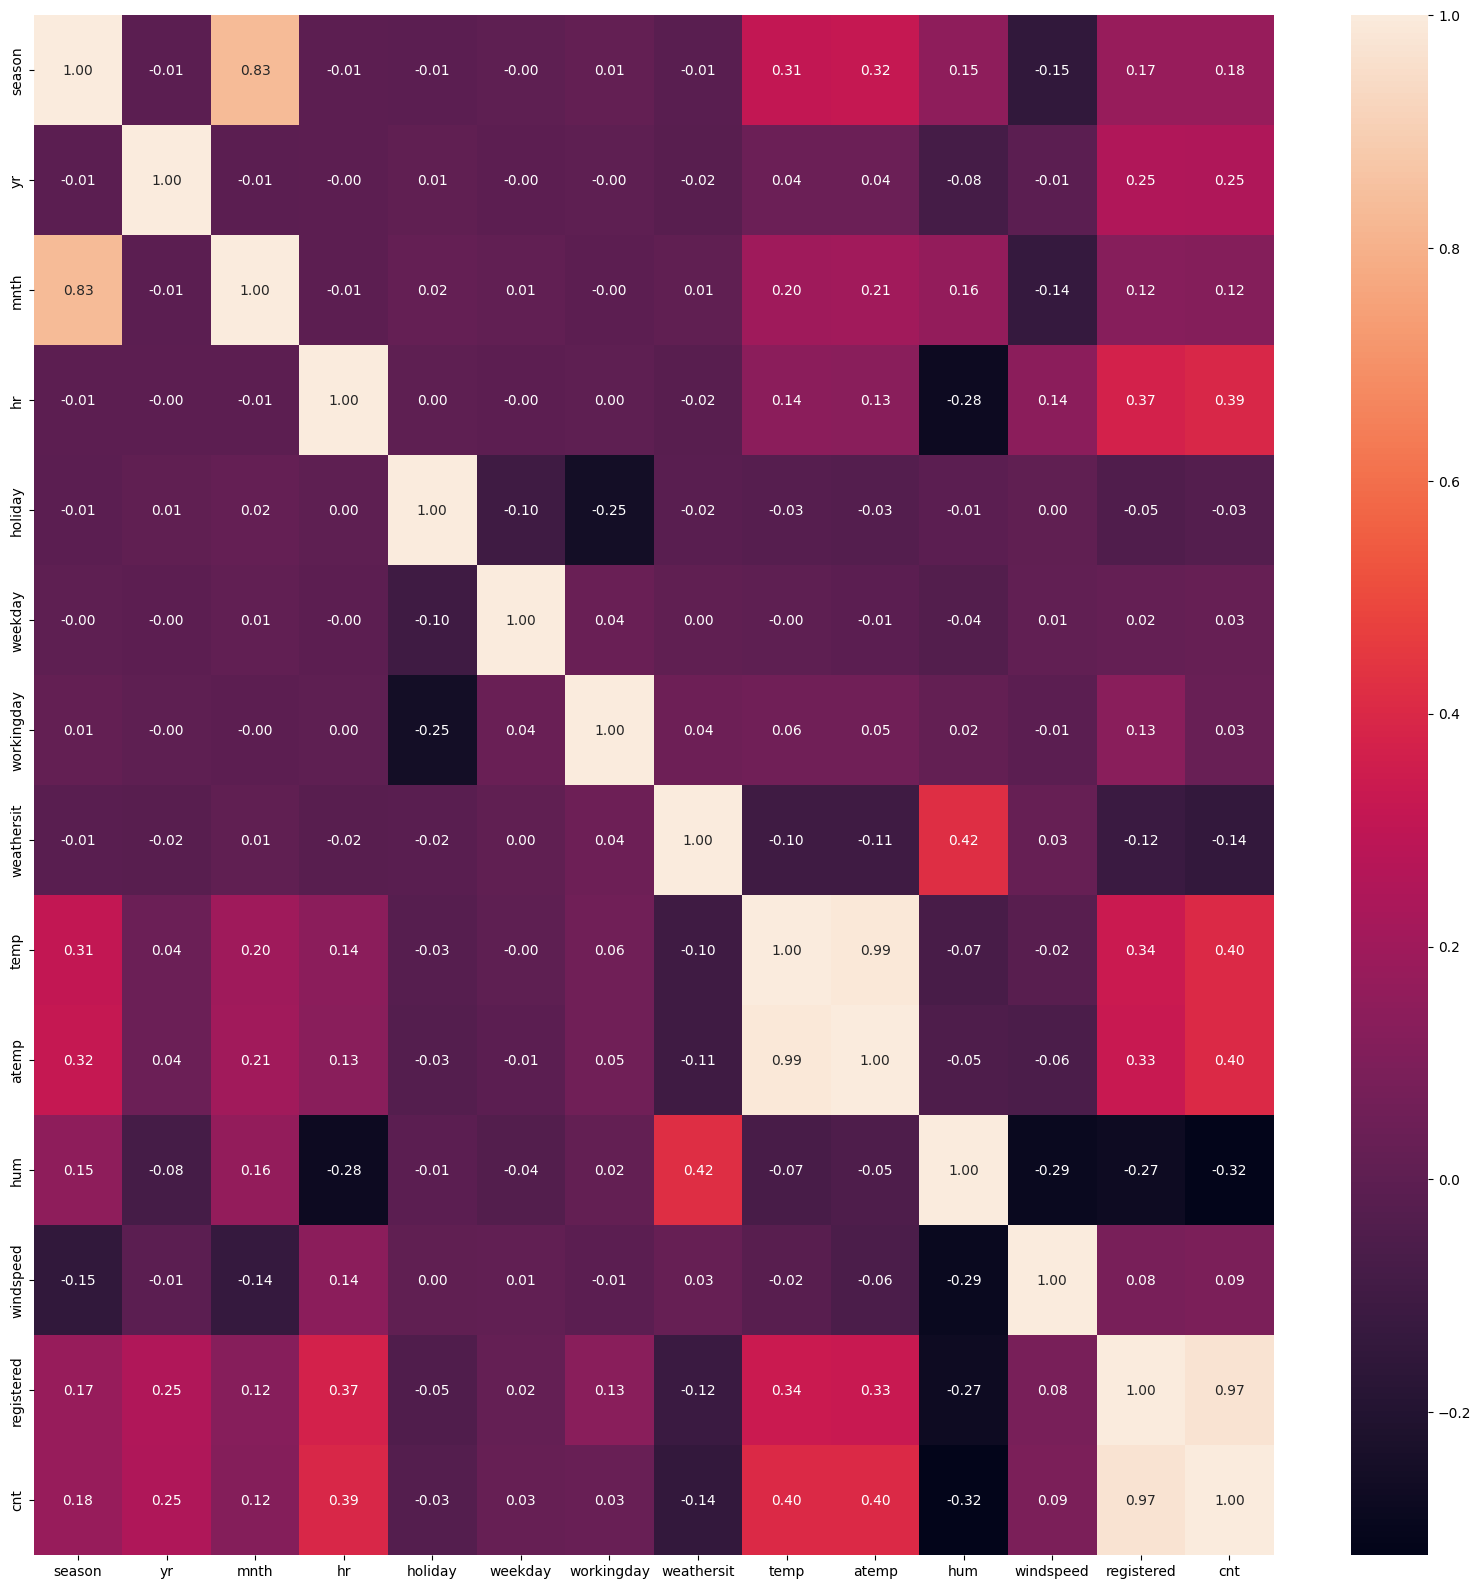

In [520]:
plt.figure(figsize=(20,20))
col = data.columns
sns.heatmap(data[col].corr(),annot=True,fmt='.2f')
plt.show()

In [521]:
# col that are highly correlated
data_2 = data.drop(['atemp', 'season', 'registered'], axis=1)

In [522]:
data_2.columns

Index(['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit',
       'temp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

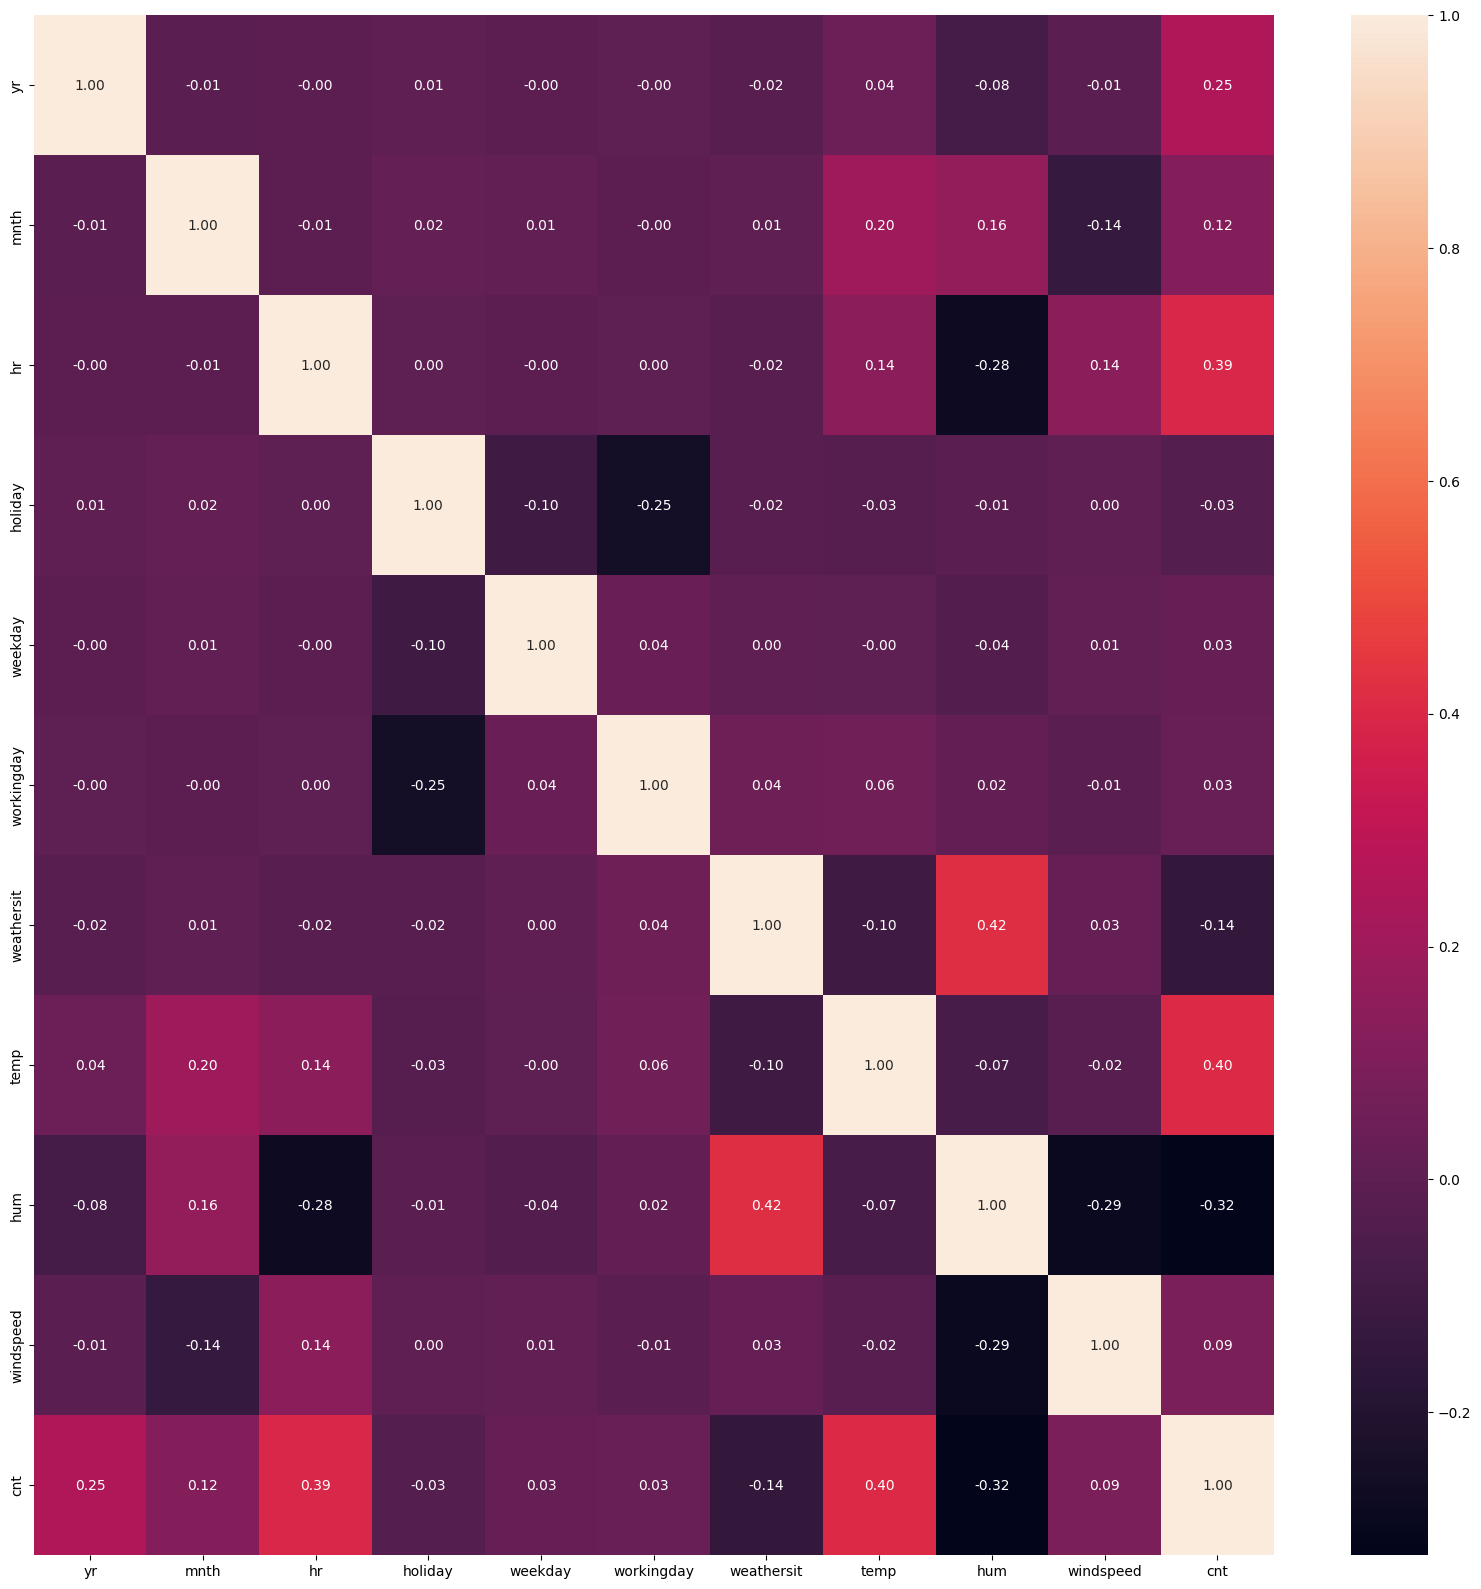

In [523]:
plt.figure(figsize=(20,20))
col = data_2.columns
sns.heatmap(data_2[col].corr(),annot=True,fmt='.2f')
plt.show()

In [524]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculating VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = data_2.columns
vif_data['VIF'] = [variance_inflation_factor(data_2.values, i) for i in range(data_2.shape[1])]

vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

       Feature        VIF
8          hum  12.069565
7         temp   8.440360
6   weathersit   7.595683
1         mnth   4.976430
2           hr   4.270447
10         cnt   3.391183
5   workingday   3.225009
9    windspeed   3.214372
4      weekday   3.057466
0           yr   2.099479
3      holiday   1.096153


In [525]:
# vif od humidity is >10 dropping it
data_2.drop('hum',axis =1 ,inplace = True)

In [526]:
# Calculating VIF again
vif_data = pd.DataFrame()
vif_data['Feature'] = data_2.columns
vif_data['VIF'] = [variance_inflation_factor(data_2.values, i) for i in range(data_2.shape[1])]

vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

      Feature       VIF
7        temp  7.533185
6  weathersit  4.940164
1        mnth  4.423521
2          hr  4.269408
8   windspeed  3.205684
9         cnt  3.159091
5  workingday  3.145685
4     weekday  2.993587
0          yr  2.072329
3     holiday  1.091549


In [527]:
# now we have no multicolinearity in cols

# Model Training

In [528]:
#doing train_Test Split

from sklearn.model_selection import train_test_split

X = data_2.iloc[:,0:-1]
y = data_2['cnt']

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=10)

In [529]:
X_train.shape,X_test.shape

((13034, 9), (4345, 9))

In [530]:
y_train.shape,y_test.shape

((13034,), (4345,))

In [531]:
# scaling our data using Standard Sclar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Algorithms Used for Model Training:

• Linear Regression  
• Random Forest Regressor   
• XGBoost Regressor

In [532]:
# lets start training our model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

LinearRegressionmodel = LinearRegression()
RandomForestmodel = RandomForestRegressor()
xgboostmodel = XGBRegressor()

In [533]:
# Lets train our models

LinearRegressionmodel.fit(X_train_scaled,y_train)
RandomForestmodel.fit(X_train_scaled,y_train)
xgboostmodel.fit(X_train_scaled,y_train)

print("all models are trained")

all models are trained


# model Evaluation

In [534]:
print(f"Train Accuracy of LinearRegressionmodel is {(LinearRegressionmodel.score(X_train_scaled,y_train)*100):.2f}")

Train Accuracy of LinearRegressionmodel is 35.67


In [535]:
print(f"Train Accuracy of RandomForestmodel is {(RandomForestmodel.score(X_train_scaled,y_train)*100):.2f}")


Train Accuracy of RandomForestmodel is 99.04


In [536]:
print(f"Train Accuracy of xgboostmodel is {(xgboostmodel.score(X_train_scaled,y_train)*100):.2f}")

Train Accuracy of xgboostmodel is 96.99


In [537]:
from sklearn.metrics import r2_score, mean_squared_error

# predictions
lr_pred = LinearRegressionmodel.predict(X_test_scaled)
rf_pred = RandomForestmodel.predict(X_test_scaled)
xgb_pred = xgboostmodel.predict(X_test_scaled)

# evaluation
print(" Linear Regression R2:", r2_score(y_test, lr_pred))
print(" Random Forest R2:", r2_score(y_test, rf_pred))
print(" XGBoost R2:", r2_score(y_test, xgb_pred))


 Linear Regression R2: 0.35119357549690944
 Random Forest R2: 0.9290948322360831
 XGBoost R2: 0.42140042781829834


In [538]:
print("Linear Regression mse:", round(mean_squared_error(y_test, lr_pred),2) )
print("Random Forest mse:", round(mean_squared_error(y_test, rf_pred),2) )
print("XGBoost mse:", round(mean_squared_error(y_test, xgb_pred),2) )

Linear Regression mse: 20879.93
Random Forest mse: 2281.87
XGBoost mse: 18620.52


# HyperParameter Tuning

In [539]:
from sklearn.model_selection import GridSearchCV

In [540]:
from sklearn.linear_model import Ridge

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print("Best alpha:", ridge_grid.best_params_)
print("Best alpha:", ridge_grid.best_score_)

Best alpha: {'alpha': 10}
Best alpha: 0.35615050075143306


In [541]:
from sklearn.linear_model import Lasso

lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid=lasso_params,
    cv=5,
    scoring='r2'
)

lasso_grid.fit(X_train_scaled, y_train)

# best results
print("Best alpha:", lasso_grid.best_params_)
print("Best CV Score:", lasso_grid.best_score_)

Best alpha: {'alpha': 0.001}
Best CV Score: 0.35615001136521657


In [542]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print("Best RandomForest model params using gridsearch cv:", rf_grid.best_params_)
print("Best RandomForest model Score using gridsearch cv:", rf_grid.best_score_)


Best RandomForest model params using gridsearch cv: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best RandomForest model Score using gridsearch cv: 0.9245847885974469


In [543]:
xgb_params = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid=xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

print("Best XGB model Params from grid search cv:", xgb_grid.best_params_)
print("Best XGB model Score using gridsearch cv :", xgb_grid.best_score_)

Best XGB model Params from grid search cv: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}
Best XGB model Score using gridsearch cv : 0.9400590260823568


In [545]:
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

rf_pred = best_rf.predict(X_test_scaled)
xgb_pred = best_xgb.predict(X_test_scaled)

print("Tuned RandomForest R2:", r2_score(y_test, rf_pred))
print("Tuned XGBoost R2:", r2_score(y_test, xgb_pred))

Tuned RandomForest R2: 0.9311453015249348
Tuned XGBoost R2: 0.488735556602478


In [548]:
final_model = rf_grid.best_estimator_

In [549]:
final_model

RandomForestRegressor(min_samples_split=5, n_estimators=200, random_state=42)